# FFT and IFFT Utilities
Reusable Python code snippets for 1D and 2D Fast Fourier Transform, suitable for sonar and general DSP analysis.

---

## 1. 1D FFT and IFFT Example


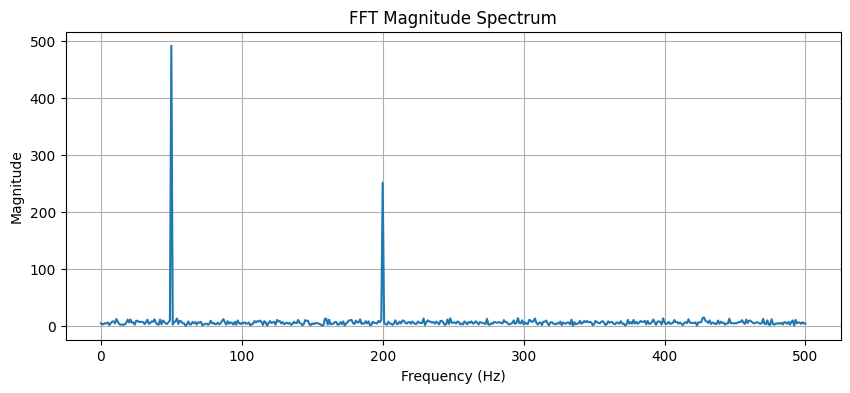

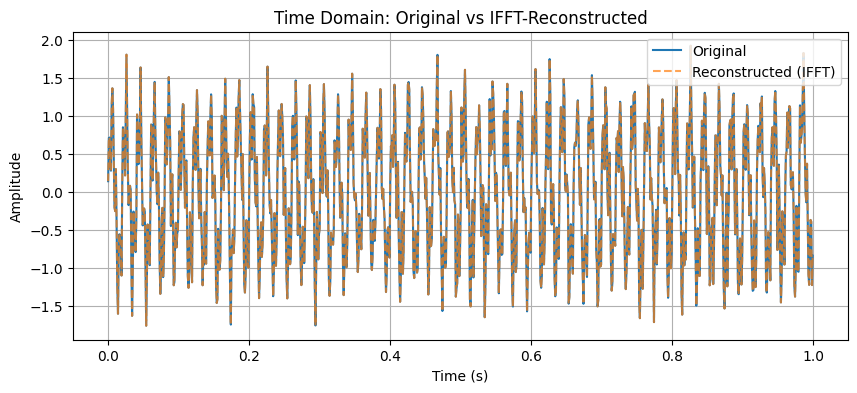

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a test signal (sum of 2 sine waves + noise)
fs = 1000  # Sampling rate (Hz)
t = np.arange(0, 1.0, 1/fs)
f1, f2 = 50, 200  # Frequencies (Hz)
signal = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t) + 0.2*np.random.randn(len(t))

# FFT
N = len(signal)
freqs = np.fft.rfftfreq(N, 1/fs)
fft_vals = np.fft.rfft(signal)

# Magnitude Spectrum
plt.figure(figsize=(10,4))
plt.plot(freqs, np.abs(fft_vals))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# IFFT (reconstruction)
recon = np.fft.irfft(fft_vals)
plt.figure(figsize=(10,4))
plt.plot(t, signal, label='Original')
plt.plot(t, recon, '--', label='Reconstructed (IFFT)', alpha=0.7)
plt.legend()
plt.title('Time Domain: Original vs IFFT-Reconstructed')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


## 2. 2D FFT Example (for Image/Sonar Data)


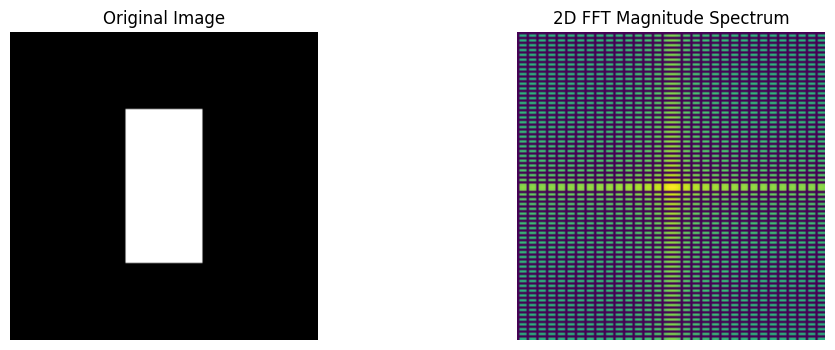

In [2]:
# Create a synthetic 2D image (for demo)
img = np.zeros((128, 128))
img[32:96, 48:80] = 1  # Add a rectangle

# 2D FFT
f_img = np.fft.fft2(img)
fshift = np.fft.fftshift(f_img)
magnitude_spectrum = np.log(np.abs(fshift) + 1e-6)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(magnitude_spectrum, cmap='viridis')
plt.title('2D FFT Magnitude Spectrum')
plt.axis('off')
plt.show()
